<a href="https://colab.research.google.com/github/Elliotamari/Machine-Learning-Projects/blob/main/Solving%20Coding%20Problems%20/%20DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
!curl -o NBA_2024_cleaned.csv https://raw.githubusercontent.com/annlntv/sg_da/main/NBA_2024_cleaned.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  463k  100  463k    0     0  1184k      0 --:--:-- --:--:-- --:--:-- 1186k


In [3]:
import pandas as pd
df = pd.read_csv("NBA_2024_cleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3621 entries, 0 to 3620
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  3621 non-null   object 
 1   Pos     3621 non-null   object 
 2   Age     3621 non-null   int64  
 3   Tm      3621 non-null   object 
 4   G       3621 non-null   int64  
 5   GS      3621 non-null   int64  
 6   MP      3621 non-null   float64
 7   FG      3621 non-null   float64
 8   FGA     3621 non-null   float64
 9   FG%     3621 non-null   float64
 10  3P      3621 non-null   float64
 11  3PA     3621 non-null   float64
 12  3P%     3621 non-null   float64
 13  2P      3621 non-null   float64
 14  2PA     3621 non-null   float64
 15  2P%     3621 non-null   float64
 16  eFG%    3621 non-null   float64
 17  FT      3621 non-null   float64
 18  FTA     3621 non-null   float64
 19  FT%     3621 non-null   float64
 20  ORB     3621 non-null   float64
 21  DRB     3621 non-null   float64
 22  

9. NBA player statistics

In [5]:
# Compute correlation of all numeric columns with PTS
correlation_matrix = df.corr(numeric_only=True)  # Avoids deprecation warning
correlations_with_pts = correlation_matrix["PTS"].drop("PTS")  # Exclude self-correlation

# Get the top 5 most correlated metrics
top_5_correlated_metrics = correlations_with_pts.abs().sort_values(ascending=False).head(5).index.tolist()

# Format the output
output_string = ", ".join(top_5_correlated_metrics)

# Print the top 5 metrics most correlated with PTS
print(f"Top 5 most correlated metrics with PTS: {output_string}")

Top 5 most correlated metrics with PTS: FG, FGA, 2PA, 2P, FT


10. NBA player statistics

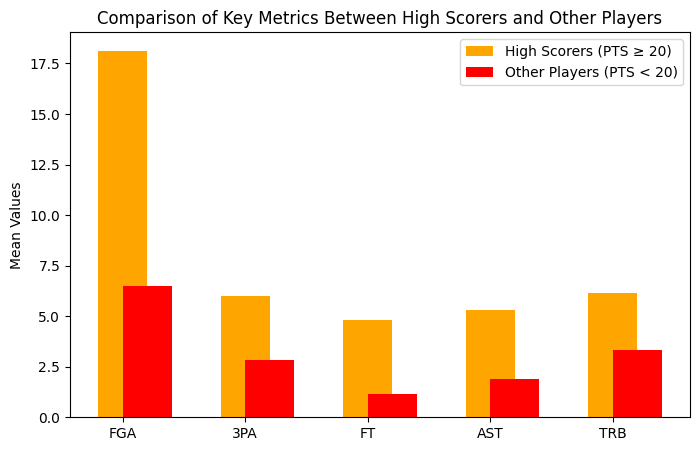

Plot saved as: nba_high_scorers_comparison.png


In [4]:
# Define high scorers (PTS >= 20) and other players
high_scorers = df[df["PTS"] >= 20]
other_players = df[df["PTS"] < 20]

# Selected metrics for comparison
metrics = ["FGA", "3PA", "FT", "AST", "TRB"]

# Compute mean values for each group
high_scorers_means = high_scorers[metrics].mean()
other_players_means = other_players[metrics].mean()

# Plot comparison
plt.figure(figsize=(8, 5))
x = range(len(metrics))

plt.bar(x, high_scorers_means, width=0.4, label="High Scorers (PTS ≥ 20)", align="center", color="orange")
plt.bar(x, other_players_means, width=0.4, label="Other Players (PTS < 20)", align="edge", color="red")

plt.xticks(x, metrics)
plt.ylabel("Mean Values")
plt.title("Comparison of Key Metrics Between High Scorers and Other Players")
plt.legend()

# Save and show the plot
plot_path = "nba_high_scorers_comparison.png"
plt.savefig(plot_path)
plt.show()

# Print the saved plot path for reference
print(f"Plot saved as: {plot_path}")